# Ejercicio 1(c) - Patrones de Demanda Espacio-Temporales en NYC

## Introducción
El objetivo de este ejercicio es analizar cómo varía la demanda de taxis en Nueva York según la zona de la ciudad y el momento del día. Para ello, se combinan dos enfoques complementarios: una clasificación local de la demanda por zona y un agrupamiento de barrios con comportamientos temporales similares.

La lógica general del análisis parte de una idea sencilla pero importante: no todas las zonas de la ciudad tienen el mismo volumen de actividad, por lo que comparar valores absolutos de demanda puede conducir a interpretaciones sesgadas. Por este motivo, se trabaja con medidas relativas dentro de cada barrio y, posteriormente, con perfiles temporales estandarizados para identificar patrones comparables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Carga de Datos (Data Mart)
En primer lugar, se carga el dataset agregado ex1c_demand_patterns, que ya contiene la media histórica de viajes por zona, si el día es laborable o fin de semana, y el bloque horario de 3 horas. Este archivo se cruza además con el catálogo taxi_zone_lookup.csv para incorporar la información geográfica de Borough y Zone, lo que mejora la interpretación de los resultados.

El dataset final contiene 4208 filas, lo que refleja la combinación de zonas, franjas horarias y tipo de día utilizada para el análisis. A partir de esta base, se construyen dos variables de apoyo: hour_range, que transforma los bloques horarios en etiquetas legibles como 00-03 o 21-24, y time_context, que distingue entre días laborables (W) y fines de semana (Wend).

In [2]:
ruta_datos = "../data/aggregated/ex1c/ex1c_demand_patterns" 
df = pd.read_parquet(ruta_datos)

# Cargar el catálogo de zonas
ruta_zonas = "../data/external/taxi_zone_lookup.csv"
df_zonas = pd.read_csv(ruta_zonas)

df = df.merge(
    df_zonas[['LocationID', 'Borough', 'Zone']], 
    left_on='pu_location_id', 
    right_on='LocationID', 
    how='left'
).drop(columns=['LocationID'])

print(f"Dataset cargado: {df.shape[0]} filas.")
display(df.head())

Dataset cargado: 4208 filas.


,pu_location_id,is_weekend,hour_block_3h,avg_trips,demand_level,Borough,Zone
0,1,1,0,0.016077,Baja,EWR,Newark Airport
1,1,0,0,0.018852,Baja,EWR,Newark Airport
2,1,0,7,0.036847,Baja,EWR,Newark Airport
3,1,0,1,0.053985,Baja,EWR,Newark Airport
4,1,1,7,0.055734,Baja,EWR,Newark Airport


In [3]:
# Mapear bloques horarios a etiquetas legibles
def map_hour_block(block):
    labels = {
        0: "00-03",
        1: "03-06",
        2: "06-09",
        3: "09-12",
        4: "12-15",
        5: "15-18",
        6: "18-21",
        7: "21-24",
    }
    return labels.get(block, "unknown")

df["hour_range"] = df["hour_block_3h"].map(map_hour_block)

# Crear contexto temporal interpretable
df["time_context"] = np.where(
    df["is_weekend"] == 1,
    "Wend " + df["hour_range"],
    "W " + df["hour_range"]
)

display(df[["hour_block_3h", "hour_range", "time_context"]].drop_duplicates().head())

,hour_block_3h,hour_range,time_context
0,0,00-03,Wend 00-03
1,0,00-03,W 00-03
2,7,21-24,W 21-24
3,1,03-06,W 03-06
4,7,21-24,Wend 21-24


## Clasificación de Demanda Local

La primera parte metodológica consiste en clasificar la demanda de cada zona en tres niveles: Baja, Media y Alta. Esta clasificación no se realiza con umbrales globales, sino mediante terciles locales calculados dentro de cada zona, de modo que cada barrio se evalúa respecto a su propio comportamiento histórico.

Este criterio es especialmente útil porque permite comparar correctamente zonas con naturalezas muy distintas. No es razonable interpretar Midtown Manhattan y una zona residencial periférica con la misma escala absoluta, ya que sus volúmenes de movilidad responden a dinámicas urbanas diferentes. La clasificación relativa permite, por tanto, detectar qué horas son pico o valle dentro de cada contexto local, y no solo en el conjunto de la ciudad.

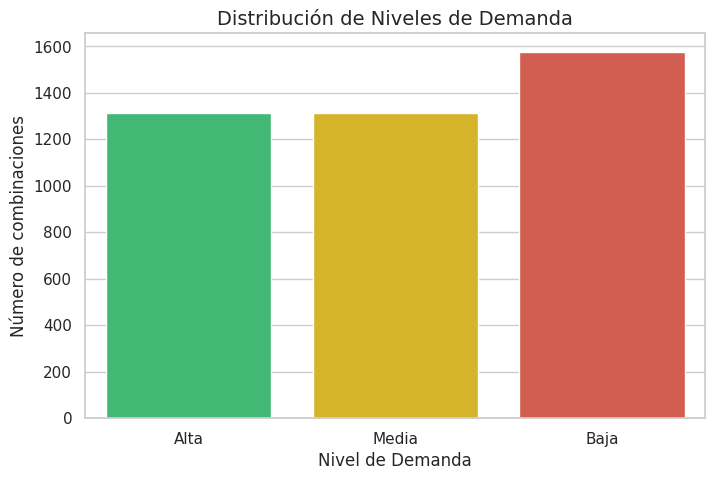

In [4]:
# Contar cuántas franjas horarias/zonas caen en cada categoría
conteo_demanda = df['demand_level'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=conteo_demanda.index,
    y=conteo_demanda.values,
    order=["Alta", "Media", "Baja"],
    hue=conteo_demanda.index,
    palette=["#e74c3c", "#f1c40f", "#2ecc71"],
    legend=False
)

plt.title("Distribución de Niveles de Demanda", fontsize=14)
plt.ylabel("Número de combinaciones")
plt.xlabel("Nivel de Demanda")
plt.show()

La distribución de niveles de demanda resulta equilibrada, lo cual es coherente con el uso de terciles. Esto confirma que el procedimiento reparte de forma homogénea las observaciones entre las tres categorías, evitando que una sola etiqueta domine el análisis por efecto del volumen agregado.

### Interpretación temporal
Una vez construida la variable temporal interpretable, el análisis explora cómo se comporta la demanda a lo largo del día. El uso de bloques de 3 horas facilita una lectura más clara de los patrones horarios, ya que reduce el ruido de la granularidad excesiva y permite observar mejor transiciones entre franjas

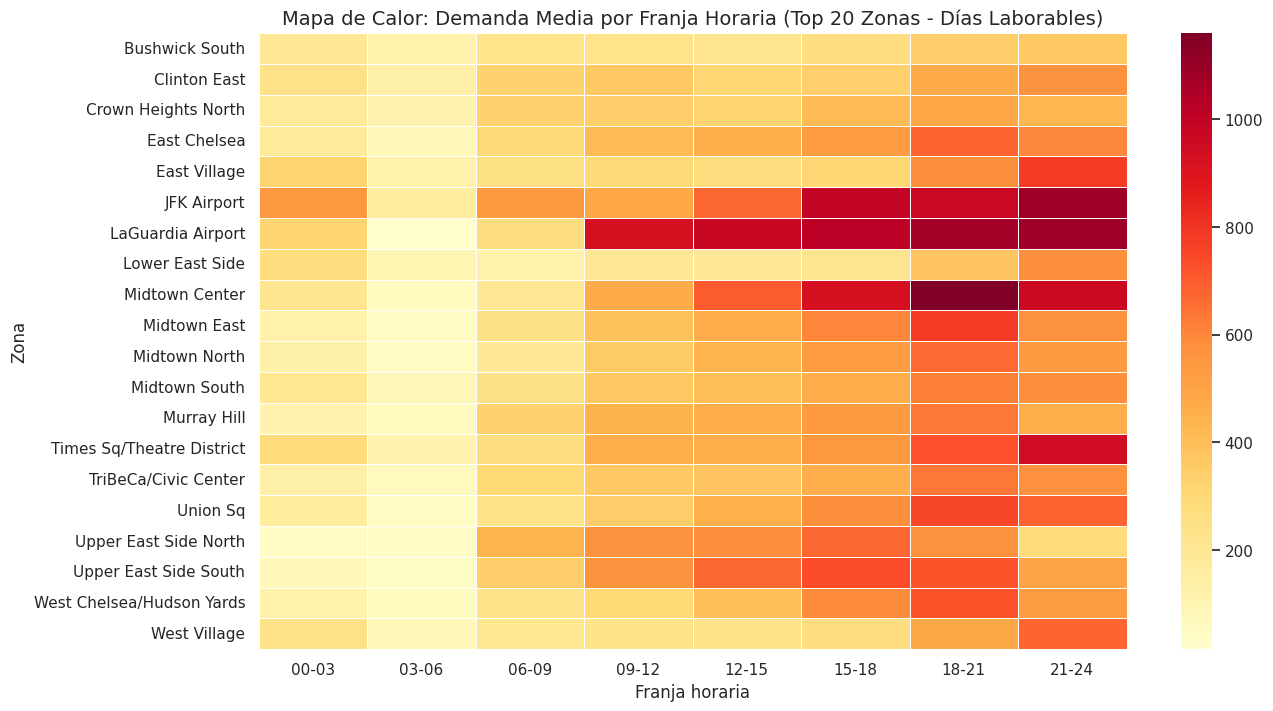

In [5]:
# 1. Identificar las 20 zonas con más viajes en promedio
top_zonas = df.groupby('Zone')['avg_trips'].sum().nlargest(20).index

# 2. Filtrar el dataframe solo para esas zonas y días laborables (is_weekend == False)
df_top = df[(df['Zone'].isin(top_zonas)) & (df['is_weekend'] == False)]

# 3. Crear una tabla pivote para el Heatmap (Filas: Zonas, Columnas: Franjas Horarias)
pivot_demanda = df_top.pivot(index='Zone', columns='hour_range', values='avg_trips')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_demanda, cmap="YlOrRd", annot=False, linewidths=.5)
plt.title("Mapa de Calor: Demanda Media por Franja Horaria (Top 20 Zonas - Días Laborables)", fontsize=14)
plt.ylabel("Zona")
plt.xlabel("Franja horaria")
plt.show()

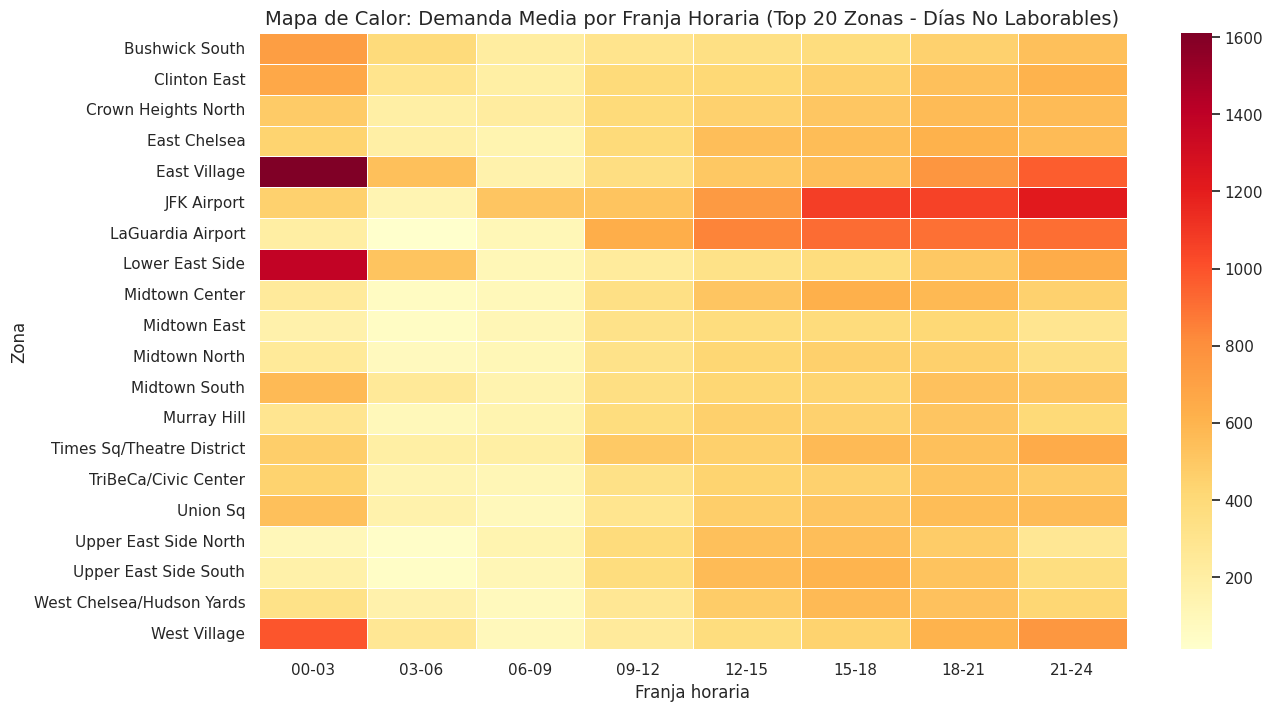

In [6]:
# 2. Filtrar el dataframe solo para esas zonas y días no laborables (is_weekend == True)
df_top = df[(df['Zone'].isin(top_zonas)) & (df['is_weekend'] == True)]

# 3. Crear una tabla pivote para el Heatmap (Filas: Zonas, Columnas: Franjas Horarias)
pivot_demanda = df_top.pivot(index='Zone', columns='hour_range', values='avg_trips')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_demanda, cmap="YlOrRd", annot=False, linewidths=.5)
plt.title("Mapa de Calor: Demanda Media por Franja Horaria (Top 20 Zonas - Días No Laborables)", fontsize=14)
plt.ylabel("Zona")
plt.xlabel("Franja horaria")
plt.show()

El análisis visual mediante mapas de calor para las zonas con mayor demanda muestra que los picos no se distribuyen de forma uniforme, sino que dependen tanto de la zona como del tipo de día. En días laborables, la demanda tiende a concentrarse en franjas asociadas a la actividad profesional y al desplazamiento urbano, mientras que en fines de semana aparecen patrones más dispersos y, en algunos casos, desplazados hacia horarios más tardíos.

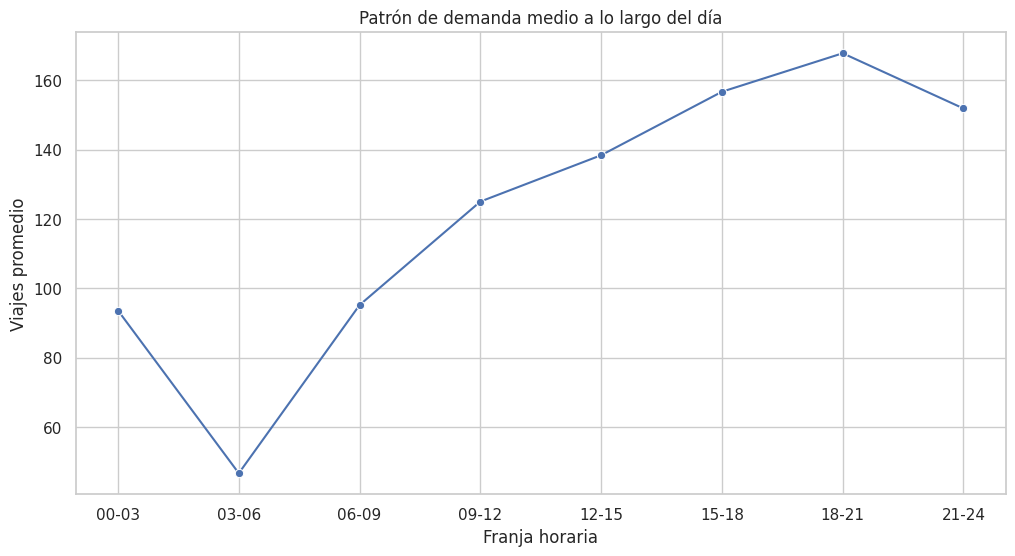

In [7]:
df_time = df.groupby("hour_range")["avg_trips"].mean().reset_index()

plt.figure()
sns.lineplot(data=df_time, x="hour_range", y="avg_trips", marker="o")

plt.title("Patrón de demanda medio a lo largo del día")
plt.xlabel("Franja horaria")
plt.ylabel("Viajes promedio")
plt.show()

El gráfico de evolución media diaria refuerza esta lectura, porque permite ver cómo la demanda global cambia a lo largo del día. Aunque el patrón agregado suaviza diferencias entre barrios, sigue mostrando que la movilidad no es constante y que existen franjas donde la actividad se intensifica de forma clara.

## Agrupación de zonas con K-Means

La segunda parte del ejercicio consiste en agrupar zonas según su patrón temporal de demanda mediante `K-Means`. Para ello, los datos se reorganizan en una matriz donde cada fila representa una zona y cada columna un contexto temporal concreto, diferenciando entre día laborable y fin de semana.

Antes de aplicar el algoritmo, se utiliza `StandardScaler` para estandarizar las variables. Este paso es fundamental, porque evita que el agrupamiento dependa únicamente del volumen absoluto de viajes y favorece que el modelo capture la forma del patrón temporal. En otras palabras, el objetivo no es solo separar zonas con mucha o poca demanda, sino detectar zonas que “se comportan parecido” a lo largo del tiempo.

El modelo se ejecuta con cuatro clústeres, lo que permite obtener perfiles relativamente diferenciados de comportamiento urbano. La distribución de zonas por clúster es desigual, con grupos de distinto tamaño, lo cual es normal en un problema de movilidad urbana, donde no todos los patrones tienen la misma frecuencia.

In [8]:
# Pivotamos: Filas = Zonas, Columnas = Contextos temporales, Valores = Viajes medios
df_pivot = df.pivot_table(
    index=['pu_location_id', 'Borough', 'Zone'],
    columns='time_context',
    values='avg_trips',
    fill_value=0 # Si una zona no tiene viajes en una franja, ponemos 0
).reset_index()

# Limpiamos los nombres de las columnas tras el pivot
df_pivot.columns.name = None

display(df_pivot.head())

,pu_location_id,Borough,Zone,W 00-03,W 03-06,W 06-09,W 09-12,W 12-15,W 15-18,W 18-21,W 21-24,Wend 00-03,Wend 03-06,Wend 06-09,Wend 09-12,Wend 12-15,Wend 15-18,Wend 18-21,Wend 21-24
0,1,EWR,Newark Airport,0.018852,0.053985,0.086975,0.080548,0.200943,0.288346,0.185090,0.036847,0.016077,0.063237,0.126474,0.109325,0.280815,0.445874,0.245445,0.055734
1,2,Queens,Jamaica Bay,0.013282,0.005998,0.022279,0.056127,0.094259,0.129820,0.097258,0.037704,0.030011,0.011790,0.039657,0.120043,0.271168,0.190782,0.096463,0.037513
2,3,Bronx,Allerton/Pelham Gardens,17.239503,18.324764,94.304199,71.128106,73.546272,83.697087,66.520137,54.150814,35.814577,19.848875,48.080386,67.327974,69.945338,76.419078,71.976420,67.758842
3,4,Manhattan,Alphabet City,53.705227,28.281919,86.721937,92.781063,68.841474,72.538132,104.777635,107.797772,255.633441,88.115756,54.819936,97.438371,111.244373,112.957128,137.555198,148.157556
4,5,Staten Island,Arden Heights,1.751928,2.938303,14.593402,10.770351,9.332048,9.858183,7.257498,4.119966,4.885316,3.138264,7.560557,9.939979,9.994641,9.012862,9.740622,6.330118


In [9]:
# Seleccionamos solo las columnas numéricas (las franjas horarias)
columnas_features = [col for col in df_pivot.columns if col not in ['pu_location_id', 'Borough', 'Zone']]
X = df_pivot[columnas_features]

# Normalizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos K-Means (vamos a buscar 4 perfiles típicos de barrios)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_pivot['Cluster'] = kmeans.fit_predict(X_scaled)

print("Número de zonas por clúster:")
print(df_pivot['Cluster'].value_counts())

Número de zonas por clúster:
Cluster
3    101
0     88
2     50
1     22
Name: count, dtype: int64


### Perfil de los clústeres
El análisis de los centroides de cada clúster permite interpretar los perfiles resultantes. Aunque el número exacto de zonas por grupo varía, sí se observan diferencias claras en su comportamiento temporal, lo que sugiere que el algoritmo ha capturado estructuras reales dentro de la demanda.

Al revisar ejemplos representativos, aparecen zonas claramente vinculadas a actividad aeroportuaria, como JFK Airport y LaGuardia Airport, que forman parte de uno de los grupos con mayor volumen total. Estas áreas presentan un comportamiento muy distinto al de barrios residenciales o mixtos, porque su demanda está más condicionada por viajes de conexión y flujos no cotidianos.

También se identifican clústeres asociados a zonas densamente urbanas de Manhattan y otras áreas con intensa actividad económica o de ocio, como Midtown Center, Times Sq/Theatre District, East Village o Gramercy. Estas zonas tienden a concentrar demanda elevada y patrones horarios más marcados, especialmente en franjas vinculadas al trabajo, la restauración, el turismo y el ocio nocturno.

Por otro lado, existen clústeres formados por zonas con menor volumen relativo o con una dinámica más equilibrada, como Carroll Gardens, Crotona Park East o Manhattanville. En estos casos, la demanda aparece más repartida en el tiempo, lo que sugiere patrones menos explosivos y posiblemente más relacionados con movilidad local cotidiana.

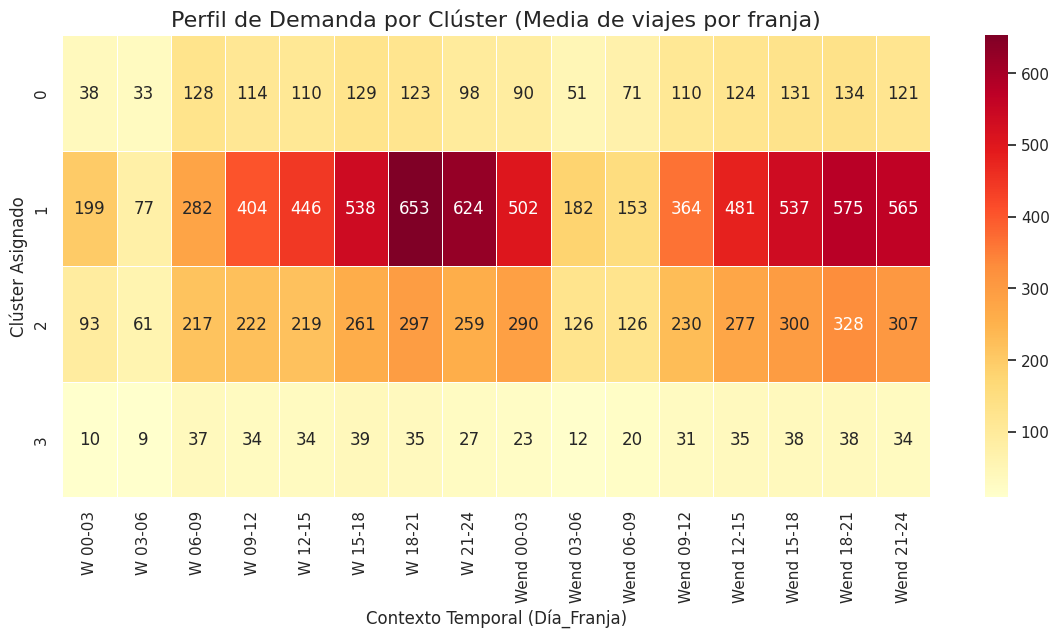

In [10]:
# Ordenamos las columnas lógicamente (Diario mañana -> tarde -> Finde...)
columnas_ordenadas = sorted(columnas_features)

# Calculamos el centroide (la media) de cada clúster en su escala original
cluster_centers = df_pivot.groupby('Cluster')[columnas_ordenadas].mean()

# Dibujamos un heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_centers, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=.5)
plt.title("Perfil de Demanda por Clúster (Media de viajes por franja)", fontsize=16)
plt.xlabel("Contexto Temporal (Día_Franja)")
plt.ylabel("Clúster Asignado")
plt.show()

In [11]:
for cluster_id in sorted(df_pivot['Cluster'].unique()):
    print(f"\n--- CLÚSTER {cluster_id} ---")
    
    zonas_cluster = df_pivot[df_pivot['Cluster'] == cluster_id].copy()
    zonas_cluster['Demanda_Total'] = zonas_cluster[columnas_features].sum(axis=1)
    
    top_5 = zonas_cluster.sort_values('Demanda_Total', ascending=False).head(5)
    
    for _, row in top_5.iterrows():
        print(f"{row['Borough']} - {row['Zone']} ({row['Demanda_Total']:.0f} viajes)")


--- CLÚSTER 0 ---
Manhattan - Yorkville East (2430 viajes)
Manhattan - Washington Heights North (2412 viajes)
Queens - Flushing (2361 viajes)
Brooklyn - Bay Ridge (2308 viajes)
Brooklyn - Downtown Brooklyn/MetroTech (2237 viajes)

--- CLÚSTER 1 ---
Queens - JFK Airport (11184 viajes)
Queens - LaGuardia Airport (10202 viajes)
Manhattan - East Village (8403 viajes)
Manhattan - Midtown Center (7601 viajes)
Manhattan - Times Sq/Theatre District (7403 viajes)

--- CLÚSTER 2 ---
Brooklyn - Williamsburg (North Side) (5152 viajes)
Manhattan - Gramercy (4960 viajes)
Brooklyn - East New York (4753 viajes)
Manhattan - Upper West Side South (4655 viajes)
Queens - Astoria (4581 viajes)

--- CLÚSTER 3 ---
Manhattan - Seaport (1203 viajes)
Brooklyn - Carroll Gardens (1078 viajes)
Manhattan - Manhattanville (1040 viajes)
Bronx - Crotona Park East (981 viajes)
Brooklyn - Madison (969 viajes)


## Conclusiones
El análisis muestra que la demanda de taxis en Nueva York presenta una estructura claramente heterogénea tanto en el espacio como en el tiempo. Las zonas no se comportan igual, y su demanda depende del tipo de área urbana, del día de la semana y de la franja horaria observada.

La clasificación local por terciles ha resultado especialmente útil porque permite identificar niveles de demanda relativos dentro de cada zona, evitando la distorsión que produciría una comparación basada exclusivamente en magnitudes absolutas. Gracias a ello, se pueden detectar horas pico y horas valle de forma más justa para cada barrio, independientemente de su tamaño o intensidad de uso.

Por su parte, el clustering con K-Means aporta una capa adicional de interpretación al agrupar zonas con curvas temporales similares. Esto permite pasar de una descripción puntual de la demanda a una visión más estructural de la ciudad, en la que se distinguen perfiles ligados a actividad aeroportuaria, urbana central, ocio o movilidad más residencial.

En conjunto, el trabajo confirma que la movilidad en taxi no responde a un patrón único, sino a múltiples lógicas de uso que conviene analizar de forma diferenciada. Desde una perspectiva aplicada, estos resultados pueden servir para optimizar la asignación de vehículos, detectar zonas con infra o sobrecobertura y apoyar decisiones de planificación urbana y logística más ajustadas a la realidad de cada área.